# SBND flux by ray-tracing through detector sub-volumes (gsimple)

Companion to [`gsimple.ipynb`](gsimple.ipynb). That notebook approximates the
volume-averaged flux by averaging plane-projected flux spectra over a set of $z$ slabs
for a fixed transverse window.

Here we instead compute the volume-averaged flux **by ray-tracing**: for every gsimple
neutrino ray, we compute the path length $L_i$ through the requested 3D volume $V$ and
form

$$\langle\Phi\rangle_V(E)\;=\;\frac{1}{V\,\mathrm{POT}}\;\sum_{i\in\text{bin}} w_i\,L_i\;.$$

For a quasi-parallel beam this equals the average of the flux through the transverse face
of $V$. The same relation underlies the standard 'track-length / volume' fluence estimator
used in transport codes (FLUKA, MCNP, Geant4 track-length tallies).

**Coordinates:** all positions in **cm** (vertex coords are converted from m to cm in
`load_gsimple`, mirroring `gsimple.ipynb`).

**Two volumes are evaluated:**

1. **`FV_split`** — two anode slabs that exclude the central cathode region: 
   $10 < |x| < 190$, $|y| < 190$, $10 < z < 450$ cm.
2. **`FV_split_truncY`** — same $10 < |x| < 190$ anode slabs as **1**; $|y| < 190$ for $10 < z < 250$ cm,
   and $-190 < y < 100$ for $250 < z < 450$ cm (downstream y-truncation).

For the full file set (~5000 ROOT files), use [`gsimple_raytrace_batch.py`](gsimple_raytrace_batch.py) to accumulate histograms in chunks (same physics, avoids loading all rays into RAM). The notebook below is intended for development / plots on a subset (`N_FILES`).

Validate full-sample batch results against [`gsimple_batch.py`](gsimple_batch.py) in
[`compare_gsimple_raytrace_batch.ipynb`](compare_gsimple_raytrace_batch.ipynb).


In [1]:
import os
import glob

import numpy as np
import matplotlib.pyplot as plt
import uproot
from tqdm import tqdm

try:
    plt.style.use("../numucc_1p0pi/presentation.mplstyle")
except OSError:
    pass


## Configuration


In [2]:
GSIMPLE_DIR = (
    "/cvmfs/sbnd.osgstorage.org/pnfs/fnal.gov/usr/sbnd/persistent/stash/"
    "fluxFiles/bnb/BooNEtoGSimple/configK-v1/july2023/neutrinoMode/"
)

# Number of files to process (set to None to process all)
N_FILES = 100

from raytrace_volume_defs import (
    BIN_CENTERS,
    E_BINS,
    E_MAX_GEV,
    RAYTRACE_VOLUME_DEFS,
    RAYTRACE_VOLUME_LABEL,
)

PDG_BY_FLAVOR = {
    "nue": 12,
    "nuebar": -12,
    "numu": 14,
    "numubar": -14,
}
FLAVORS = list(PDG_BY_FLAVOR.keys())
FLAVOR_LATEX = {
    "nue":     r"$\nu_e$",
    "nuebar":  r"$\bar{\nu}_e$",
    "numu":    r"$\nu_\mu$",
    "numubar": r"$\bar{\nu}_\mu$",
}

# Volumes: canonical definitions in raytrace_volume_defs.py
VOLUMES = dict(RAYTRACE_VOLUME_DEFS)
VOLUME_LABEL = dict(RAYTRACE_VOLUME_LABEL)


## Batch processing (all files, chunked)

Run from a shell (example):

```bash
python gsimple_raytrace_batch.py \
  --gsimple-dir /cvmfs/sbnd.osgstorage.org/pnfs/fnal.gov/usr/sbnd/persistent/stash/fluxFiles/bnb/BooNEtoGSimple/configK-v1/july2023/neutrinoMode/ \
  --batch-size 500 \
  --out-dir /exp/sbnd/data/users/munjung/flux/SBND_gsimple_raytrace \
  --save-npz /exp/sbnd/data/users/munjung/flux/SBND_gsimple_raytrace/raytrace_flux_histograms.npz
```

Outputs: `raytrace_flux_histograms.npz`, `raytrace_flux_histograms_meta.json`,
`processed_files.txt`, `skipped_files.json`. Reload in the section at the end of this notebook.


## Load gsimple entries

Same loader as `gsimple.ipynb` (vertex coords in cm, momenta in GeV, per-file POT summed
into `TOTAL_POT`).


In [6]:
def _get_pot(f):
    meta_key = next((k for k in f.keys() if "meta" in k.lower()), None)
    if meta_key is None:
        raise RuntimeError("No meta tree found; cannot read POT.")
    meta = f[meta_key]
    pot_key = next((k for k in meta.keys() if "proton" in k.lower()), None)
    if pot_key is None:
        raise RuntimeError(f"No 'protons' branch found in meta tree; keys = {list(meta.keys())}")
    return float(meta[pot_key].array(library="np").sum())


def load_gsimple(filename):
    with uproot.open(filename) as f:
        pot = _get_pot(f)
        tree = f["flux"]
        keys = tree.keys()
        if "entry/pdg" in keys:
            prefix = "entry/"
        elif "pdg" in keys:
            prefix = ""
        else:
            raise RuntimeError(f"Cannot find 'pdg' branch in {filename}; keys = {list(keys)}")

        branches = [prefix + n for n in (
            "pdg", "wgt", "vtxx", "vtxy", "vtxz", "px", "py", "pz", "E",
        )]
        arr = tree.arrays(branches, library="np")

    return {
        "pot":  pot,
        "pdg":  arr[prefix + "pdg"],
        "wgt":  arr[prefix + "wgt"],
        "vtxx": arr[prefix + "vtxx"] * 100.0,
        "vtxy": arr[prefix + "vtxy"] * 100.0,
        "vtxz": arr[prefix + "vtxz"] * 100.0,
        "px":   arr[prefix + "px"],
        "py":   arr[prefix + "py"],
        "pz":   arr[prefix + "pz"],
        "E":    arr[prefix + "E"],
    }


In [22]:
all_files = sorted(glob.glob(os.path.join(GSIMPLE_DIR, "*.root")))
files_to_process = all_files[:N_FILES] if N_FILES is not None else all_files
print(f"Found {len(all_files)} files; processing {len(files_to_process)}")

chunks = []
for fpath in tqdm(files_to_process):
    try:
        chunks.append(load_gsimple(fpath))
    except Exception as e:
        print(f"  [skip] {os.path.basename(fpath)}: {e}")

array_keys = [k for k in chunks[0].keys() if k != "pot"]
data = {k: np.concatenate([c[k] for c in chunks]) for k in array_keys}
TOTAL_POT = float(sum(c["pot"] for c in chunks))

# Precompute unit momentum direction; gsimple beam never has p == 0 in practice.
p_mag = np.sqrt(data["px"]**2 + data["py"]**2 + data["pz"]**2)
data["dx"] = data["px"] / p_mag
data["dy"] = data["py"] / p_mag
data["dz"] = data["pz"] / p_mag

print(f"Total entries : {len(data['E']):,}")
print(f"Total simulated POT: {TOTAL_POT:.4g}")


Found 5000 files; processing 100


100%|██████████| 100/100 [00:17<00:00,  5.86it/s]


Total entries : 15,105,787
Total simulated POT: 1e+09


## Ray-trace helpers

Slab-method intersection of a ray $\vec r(t)=\vec v + t\,\hat d$ ($t$ in cm, $\hat d$ unit
vector) with an axis-aligned box. We clip $t\geq 0$ so only the forward leg from the vertex
is counted (gsimple vertices sit upstream of the detector, so this is automatic for
forward-going rays).

For a union of disjoint boxes the total path length is just the sum of per-box path
lengths, which is what we use for both volumes.


In [3]:
def _slab_t(v, d, lo, hi):
    # Entry/exit parameter (in cm) for slab [lo, hi].
    # For rays parallel to the slab axis (d == 0): full overlap or no overlap, encoded
    # with +/- inf so the box-wide max/min still works.
    with np.errstate(divide="ignore", invalid="ignore"):
        t1 = (lo - v) / d
        t2 = (hi - v) / d
    t_near = np.minimum(t1, t2)
    t_far  = np.maximum(t1, t2)
    parallel = (d == 0)
    if np.any(parallel):
        inside = (v >= lo) & (v <= hi)
        t_near = np.where(parallel,  np.where(inside, -np.inf,  np.inf), t_near)
        t_far  = np.where(parallel,  np.where(inside,  np.inf, -np.inf), t_far)
    return t_near, t_far


def path_length_box(vx, vy, vz, dx, dy, dz, box):
    # Vectorized path length [cm] through an axis-aligned box, clipped to t >= 0.
    tx_n, tx_f = _slab_t(vx, dx, *box["x_range"])
    ty_n, ty_f = _slab_t(vy, dy, *box["y_range"])
    tz_n, tz_f = _slab_t(vz, dz, *box["z_range"])
    t_enter = np.maximum.reduce([tx_n, ty_n, tz_n, np.zeros_like(vx)])
    t_exit  = np.minimum.reduce([tx_f, ty_f, tz_f])
    return np.maximum(0.0, t_exit - t_enter)


def path_length_volume(data, boxes):
    # Sum over disjoint boxes -> path length [cm] through the union.
    L = np.zeros_like(data["vtxx"])
    for box in boxes:
        L += path_length_box(
            data["vtxx"], data["vtxy"], data["vtxz"],
            data["dx"], data["dy"], data["dz"], box,
        )
    return L


def volume_cm3(boxes):
    v = 0.0
    for b in boxes:
        dx = b["x_range"][1] - b["x_range"][0]
        dy = b["y_range"][1] - b["y_range"][0]
        dz = b["z_range"][1] - b["z_range"][0]
        v += dx * dy * dz
    return v


### Sanity check on path-length math

Two quick tests on a unit cube $[0,1]^3$:

* a ray entering at $(0.5,0.5,-1)$ along $\hat z$ should traverse $L=1$;
* a body-diagonal ray from $(-1,-1,-1)$ along $\hat x{+}\hat y{+}\hat z$ should traverse
  $L=\sqrt{3}$.


In [4]:
_box = dict(x_range=(0.0, 1.0), y_range=(0.0, 1.0), z_range=(0.0, 1.0))

_vx = np.array([0.5, -1.0])
_vy = np.array([0.5, -1.0])
_vz = np.array([-1.0, -1.0])
_dx = np.array([0.0, 1/np.sqrt(3)])
_dy = np.array([0.0, 1/np.sqrt(3)])
_dz = np.array([1.0, 1/np.sqrt(3)])

_L = path_length_box(_vx, _vy, _vz, _dx, _dy, _dz, _box)
print("path lengths (expect 1, sqrt(3)):", _L)
assert np.allclose(_L, [1.0, np.sqrt(3.0)], atol=1e-12)


path lengths (expect 1, sqrt(3)): [1.         1.73205081]


## Volume-averaged spectra by ray-tracing

Per energy bin:

$$\phi_b\;=\;\frac{10^4}{V_{\text{cm}^3}\,\mathrm{POT}}\;\sum_{i\,:\,E_i\in b}\,w_i\,L_i^{\text{[cm]}}\;,$$

where the $10^4$ converts $\text{cm}^{-2}$ to $\text{m}^{-2}$. Units of `phi`:
$\text{m}^{-2}\,\text{POT}^{-1}$ per 50 MeV bin.


In [25]:
def raytraced_spectrum(data, flavor, boxes, path_lengths=None):
    # Volume-averaged flux density [/m^2/POT/bin] using the track-length tally.
    if path_lengths is None:
        path_lengths = path_length_volume(data, boxes)
    V = volume_cm3(boxes)
    pdg = PDG_BY_FLAVOR[flavor]
    m = (data["pdg"] == pdg) & (path_lengths > 0)
    h, _ = np.histogram(
        data["E"][m],
        bins=E_BINS,
        weights=data["wgt"][m] * path_lengths[m],
    )
    # h has units of [wgt * cm]; divide by (V cm^3 * POT), multiply by 1e4 to go to /m^2.
    return h * 1.0e4 / (V * TOTAL_POT)


# Precompute path lengths once per volume (independent of flavor and energy).
path_lengths = {name: path_length_volume(data, boxes) for name, boxes in VOLUMES.items()}

for name, L in path_lengths.items():
    n_hit = int(np.sum(L > 0))
    L_mean = float(np.mean(L[L > 0])) if n_hit else 0.0
    print(f"{name:18s}  V = {volume_cm3(VOLUMES[name]):.4g} cm^3,  rays w/ L>0: {n_hit:,},  <L | L>0> = {L_mean:.1f} cm")

# Spectra: dict[vol_name][flavor] -> array of length len(BIN_CENTERS)
spectra = {
    name: {flav: raytraced_spectrum(data, flav, boxes, path_lengths=path_lengths[name])
           for flav in FLAVORS}
    for name, boxes in VOLUMES.items()
}


FV_split            V = 6.019e+07 cm^3,  rays w/ L>0: 2,345,065,  <L | L>0> = 416.7 cm
FV_split_truncY     V = 5.371e+07 cm^3,  rays w/ L>0: 2,342,427,  <L | L>0> = 374.8 cm


## 3D ray examples (visual check)

A few gsimple rays are drawn with the FV wireframe. The **thick colored segment** is the
portion inside the volume ($t \in [t_\mathrm{enter}, t_\mathrm{exit}]$, $t\geq 0$); its
Euclidean length should match the printed $L_i$. The faint gray line is the full ray
direction from the vertex.


Plotting 4 example rays for FV_split: [9089137, 7547061, 9003631, 2]
Saved ray_examples_FV_split -> raytrace_figures/


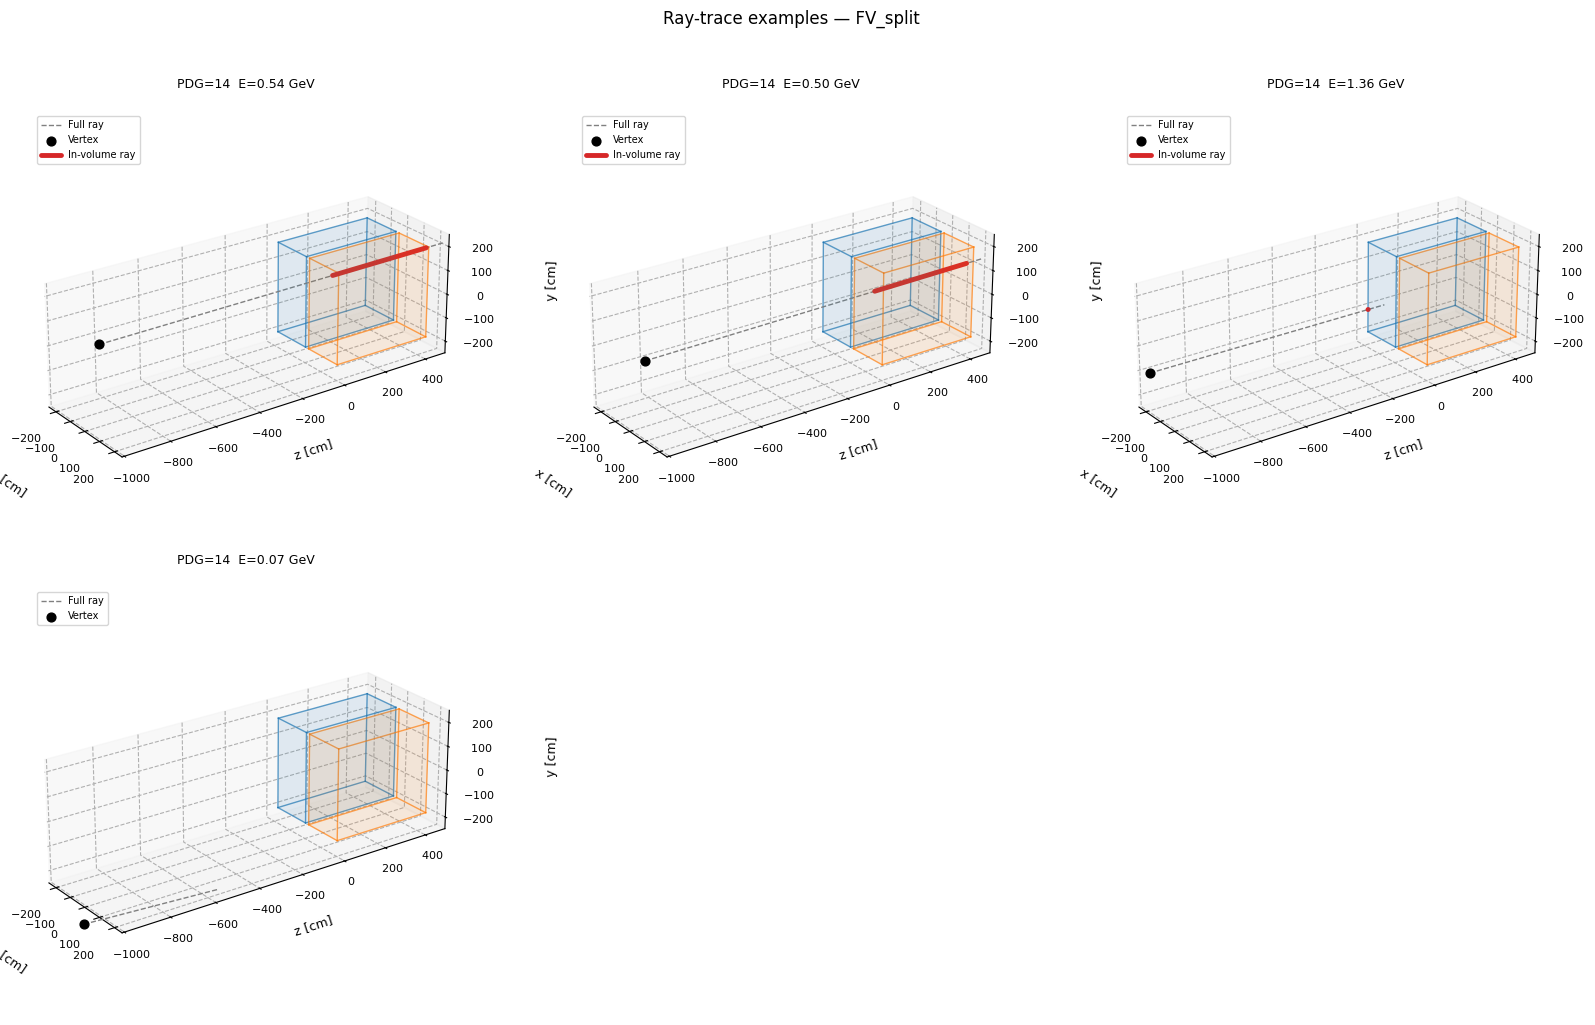

Saved ray_example_FV_split_truncY -> raytrace_figures/


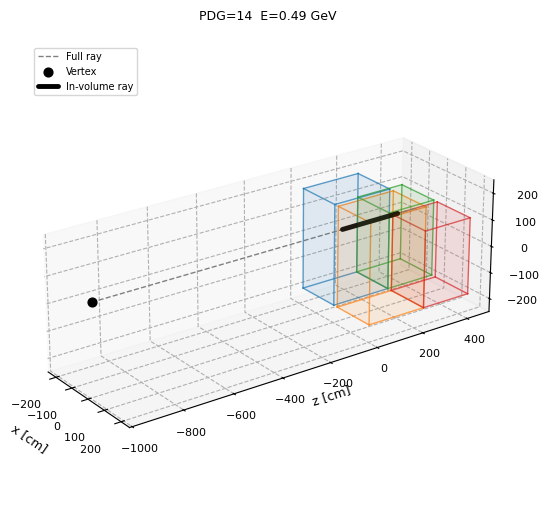

In [54]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def _plot_xyz(ax, p0, p1, **kwargs):
    """Plot segment with y/z swapped for display (physics xyz -> axes x,z,y)."""
    p0, p1 = np.asarray(p0), np.asarray(p1)
    ax.plot([p0[0], p1[0]], [p0[2], p1[2]], [p0[1], p1[1]], **kwargs)


def _scatter_xyz(ax, p, **kwargs):
    p = np.asarray(p)
    ax.scatter(p[0], p[2], p[1], **kwargs)


# 3D ray-plot view: foreshorten x (mpl x), emphasize z (mpl y after y/z display swap)
RAY3D_VIEW_ELEV = 24  # midway: default 30, tilted 18
RAY3D_VIEW_AZIM = -36  # midway: default -60, tilted -12
RAY3D_LABELPAD = 14
RAY3D_LABEL_FONTSIZE = 9
RAY3D_XY_LIMIT = 250  # fixed limits on mpl x (physics x) and mpl z (physics y)
RAY3D_Z_LIMIT_UPPER = 500  # mpl y = physics z
RAY3D_Z_OFFSET_BELOW_VTX = 10  # cm below vertex for z-axis lower limit
RAY3D_SAVE_FIGS = True
RAY3D_FIG_DIR = "raytrace_figures"


def _style_ray3d_axes(ax):
    ax.set_xlabel("x [cm]", labelpad=RAY3D_LABELPAD, fontsize=RAY3D_LABEL_FONTSIZE)
    ax.set_ylabel("z [cm]", labelpad=RAY3D_LABELPAD + 10, fontsize=RAY3D_LABEL_FONTSIZE)
    ax.set_zlabel("y [cm]", labelpad=RAY3D_LABELPAD + 10, fontsize=RAY3D_LABEL_FONTSIZE)
    ax.tick_params(axis="x", pad=6, labelsize=8)
    ax.tick_params(axis="y", pad=6, labelsize=8)
    ax.tick_params(axis="z", pad=6, labelsize=8)
    ax.view_init(elev=RAY3D_VIEW_ELEV, azim=RAY3D_VIEW_AZIM)


def _set_ray3d_limits(ax, p_vtx, p_end, segs):
    """Fixed x/y window; z from vertex-10 to 500 cm; equal cm per axis (true scale)."""
    z_lo = float(p_vtx[2]) - RAY3D_Z_OFFSET_BELOW_VTX
    z_hi = float(RAY3D_Z_LIMIT_UPPER)
    x_span = 2.0 * RAY3D_XY_LIMIT
    y_span = z_hi - z_lo  # mpl y = physics z
    z_span = 2.0 * RAY3D_XY_LIMIT  # mpl z = physics y
    ax.set_xlim(-RAY3D_XY_LIMIT, RAY3D_XY_LIMIT)
    ax.set_ylim(z_lo, z_hi)
    ax.set_zlim(-RAY3D_XY_LIMIT, RAY3D_XY_LIMIT)
    try:
        ax.set_box_aspect((x_span, y_span, z_span))
    except AttributeError:
        pass
    # mpl y = physics z: avoid scientific notation on tick labels
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)


def _finalize_ray3d_fig(fig, ax=None):
    """Margins and label padding so x/y labels stay inside the figure (true-aspect 3D)."""
    fig.subplots_adjust(left=0.16, bottom=0.14, right=0.84, top=0.94)
    if ax is not None:
        ax.xaxis.labelpad = 6
        ax.yaxis.labelpad = 6
        ax.zaxis.labelpad = 8


def _save_ray3d_fig(fig, name):
    if not RAY3D_SAVE_FIGS:
        return
    os.makedirs(RAY3D_FIG_DIR, exist_ok=True)
    for ext in ("png", "pdf"):
        fig.savefig(
            os.path.join(RAY3D_FIG_DIR, f"{name}.{ext}"),
            dpi=200,
            bbox_inches="tight",
            pad_inches=0.35,
        )
    print(f"Saved {name} -> {RAY3D_FIG_DIR}/")


def _ray_box_interval(vx, vy, vz, dx, dy, dz, box):
    """Return (t_enter, t_exit) in cm for one box, or None if no forward intersection."""
    tx_n, tx_f = _slab_t(np.array([vx]), dx, *box["x_range"])
    ty_n, ty_f = _slab_t(np.array([vy]), dy, *box["y_range"])
    tz_n, tz_f = _slab_t(np.array([vz]), dz, *box["z_range"])
    t_enter = float(max(tx_n[0], ty_n[0], tz_n[0], 0.0))
    t_exit = float(min(tx_f[0], ty_f[0], tz_f[0]))
    if not np.isfinite(t_enter) or not np.isfinite(t_exit) or t_exit <= t_enter:
        return None
    return t_enter, t_exit


def _point_on_ray(vx, vy, vz, dx, dy, dz, t):
    return np.array([vx + dx * t, vy + dy * t, vz + dz * t])


def _wireframe_box(ax, box, color="C0", alpha=0.35, lw=1.0):
    x0, x1 = box["x_range"]
    y0, y1 = box["y_range"]
    z0, z1 = box["z_range"]
    corners = np.array([
        [x0, y0, z0], [x1, y0, z0], [x1, y1, z0], [x0, y1, z0],
        [x0, y0, z1], [x1, y0, z1], [x1, y1, z1], [x0, y1, z1],
    ])
    edges = [
        (0, 1), (1, 2), (2, 3), (3, 0),
        (4, 5), (5, 6), (6, 7), (7, 4),
        (0, 4), (1, 5), (2, 6), (3, 7),
    ]
    for i, j in edges:
        _plot_xyz(ax, corners[i], corners[j], color=color, alpha=alpha, lw=lw)
    # light faces for depth cue
    faces = [
        [corners[i] for i in (0, 1, 2, 3)],
        [corners[i] for i in (4, 5, 6, 7)],
        [corners[i] for i in (0, 1, 5, 4)],
        [corners[i] for i in (2, 3, 7, 6)],
        [corners[i] for i in (0, 3, 7, 4)],
        [corners[i] for i in (1, 2, 6, 5)],
    ]
    # swap y<->z for display
    faces_plot = [np.array([[v[0], v[2], v[1]] for v in face]) for face in faces]
    ax.add_collection3d(
        Poly3DCollection(faces_plot, facecolor=color, edgecolor="none", alpha=0.06)
    )


def _segments_in_volume(vx, vy, vz, dx, dy, dz, boxes):
    segs = []
    for box in boxes:
        iv = _ray_box_interval(vx, vy, vz, dx, dy, dz, box)
        if iv is None:
            continue
        t0, t1 = iv
        p0 = _point_on_ray(vx, vy, vz, dx, dy, dz, t0)
        p1 = _point_on_ray(vx, vy, vz, dx, dy, dz, t1)
        segs.append((p0, p1, t1 - t0))
    return segs


def plot_ray_example(ax, idx, data, boxes, L_calc, title_extra="", ray_color="C3"):
    vx = float(data["vtxx"][idx])
    vy = float(data["vtxy"][idx])
    vz = float(data["vtxz"][idx])
    dx, dy, dz = float(data["dx"][idx]), float(data["dy"][idx]), float(data["dz"][idx])
    E = float(data["E"][idx])
    pdg = int(data["pdg"][idx])

    for ib, box in enumerate(boxes):
        _wireframe_box(ax, box, color=f"C{ib}", alpha=0.7)
        # _wireframe_box(ax, box, color="C0", alpha=0.7)

    segs = _segments_in_volume(vx, vy, vz, dx, dy, dz, boxes)
    L_seg = sum(s[2] for s in segs)

    # display ray: from vertex to a bit past last in-volume exit (or fixed length if miss)
    if segs:
        t_far = max(
            np.dot(s[1] - np.array([vx, vy, vz]), [dx, dy, dz]) for s in segs
        )
        t_end = t_far + 80.0
    else:
        t_end = 600.0
    p_vtx = np.array([vx, vy, vz])
    p_end = _point_on_ray(vx, vy, vz, dx, dy, dz, t_end)
    _plot_xyz(ax, p_vtx, p_end, color="0.5", lw=1.0, linestyle="--", label="Full ray")
    _scatter_xyz(ax, p_vtx, color="k", s=40, depthshade=False, label="Vertex")

    for k, (p0, p1, Lk) in enumerate(segs):
        _plot_xyz(ax, p0, p1, color=ray_color, lw=3.5, solid_capstyle="round", label="In-volume ray") #,
                # label=f"in-volume seg {k+1} ({Lk:.1f} cm)" if k == 0 else f"seg {k+1} ({Lk:.1f} cm)")

    _style_ray3d_axes(ax)
    ok = np.isclose(L_seg, L_calc, rtol=1e-5, atol=1e-4)
    flag = "OK" if ok else "MISMATCH"
    ax.set_title(
        # f"ray #{idx}  PDG={pdg}  E={E:.2f} GeV\n"
        # f"$L_\\mathrm{{calc}}$={L_calc:.2f} cm,  $\\sum L_\\mathrm{{seg}}$={L_seg:.2f} cm  [{flag}]\n",
        # f"v=({vx:.0f},{vy:.0f},{vz:.0f})  $\hat d$=({dx:.3f},{dy:.3f},{dz:.3f}){title_extra}",
        f"PDG={pdg}  E={E:.2f} GeV\n",
        fontsize=9,
    )
    _set_ray3d_limits(ax, p_vtx, p_end, segs)
    ax.legend(fontsize=7, loc="upper left")


def pick_example_indices(L, data, boxes, n_each=2):
    """Pick a small set of illustrative ray indices."""
    idx = {}
    hit = np.where(L > 0)[0]
    if len(hit):
        idx["longest"] = int(hit[np.argmax(L[hit])])
        idx["median"] = int(hit[len(hit) // 2])
        short = hit[L[hit] > 1.0]
        if len(short):
            idx["short"] = int(short[np.argmin(L[short])])
    miss = np.where(L == 0)[0]
    if len(miss):
        # prefer a ray whose vertex is near the cathode gap (|x| < 10) but forward-going
        near_gap = miss[(np.abs(data["vtxx"][miss]) < 30) & (data["dz"][miss] > 0.5)]
        idx["miss_cathode"] = int(near_gap[0]) if len(near_gap) else int(miss[0])
    return list(dict.fromkeys(idx.values()))  # preserve order, unique


# --- plot examples for FV_split ---
vol_name = "FV_split"
boxes = VOLUMES[vol_name]
L_vol = path_lengths[vol_name]
example_idx = pick_example_indices(L_vol, data, boxes)
print(f"Plotting {len(example_idx)} example rays for {vol_name}: {example_idx}")

ncols = min(3, len(example_idx))
nrows = int(np.ceil(len(example_idx) / ncols))
fig = plt.figure(figsize=(5.5 * ncols, 5 * nrows))
for i, idx in enumerate(example_idx):
    ax = fig.add_subplot(nrows, ncols, i + 1, projection="3d")
    plot_ray_example(ax, idx, data, boxes, float(L_vol[idx]))
fig.suptitle(f"Ray-trace examples — {vol_name}", fontsize=12, y=1.02)
plt.tight_layout()
_save_ray3d_fig(fig, f"ray_examples_{vol_name}")
plt.show()

# --- one panel for FV_split_truncY (downstream y-truncated slabs, z > 250) ---
vol_name2 = "FV_split_truncY"
boxes2 = VOLUMES[vol_name2]
L2 = path_lengths[vol_name2]
# ray through downstream slab (|x| > 10, z > 250, y in truncated range)
dz_ok = data["dz"] > 0.3
in_dn = (
    (np.abs(data["vtxx"]) > 20) & (np.abs(data["vtxx"]) < 150)
    & (data["vtxy"] > 50) & (data["vtxy"] < 150)
    & (L2 > 0) & dz_ok
)
idx_dn = int(np.where(in_dn)[0][5]) if np.any(in_dn) else pick_example_indices(L2, data, boxes2)[0]

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
plot_ray_example(
    ax, idx_dn, data, boxes2, float(L2[idx_dn]),
    title_extra=f"\n({vol_name2}, downstream block)",
    ray_color="k",
)
_finalize_ray3d_fig(fig, ax)
_save_ray3d_fig(fig, f"ray_example_{vol_name2}")
plt.show()


## Spectra per volume


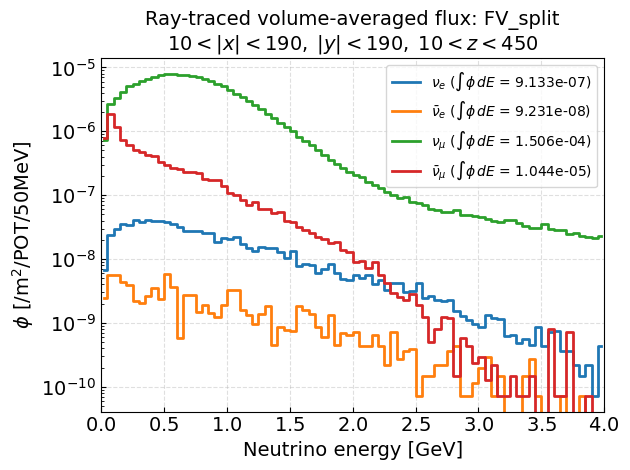

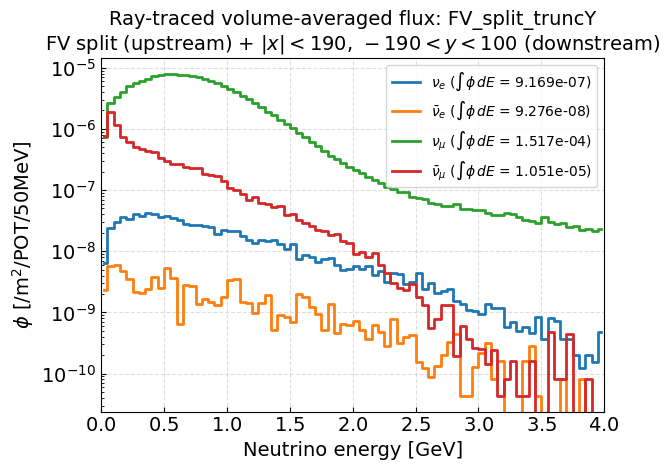

In [9]:
for vol_name in VOLUMES:
    fig, ax = plt.subplots()
    for flav in FLAVORS:
        spec = spectra[vol_name][flav]
        integ = float(np.sum(spec))
        ax.step(
            BIN_CENTERS,
            spec,
            where="mid",
            label=rf"{FLAVOR_LATEX[flav]} ($\int\phi\,dE$ = {integ:.3e})",
        )
    ax.set_xlim(0, E_MAX_GEV)
    ax.set_xlabel("Neutrino energy [GeV]")
    ax.set_ylabel(r"$\phi$ [/m$^2$/POT/50MeV]")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=10)
    ax.set_title(f"Ray-traced volume-averaged flux: {vol_name}\n{VOLUME_LABEL[vol_name]}")
    plt.tight_layout()
    plt.show()


## Per-flavor comparison: `FV_split` vs `FV_split_truncY`

The downstream y-truncation in `FV_split_truncY` removes the high-$y$ portion of the
detector that on average sees more upward-pointing rays from the BNB target / horn, so we
expect the flux to drop modestly for the truncated volume — most visibly at higher
energies in $\nu_e$ / $\bar\nu_e$ from kaon decay.


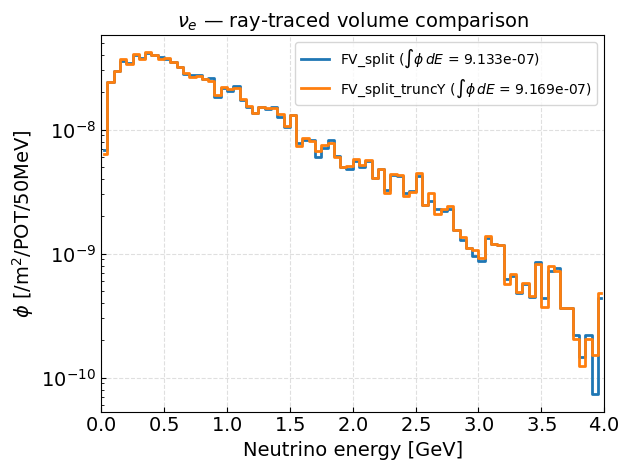

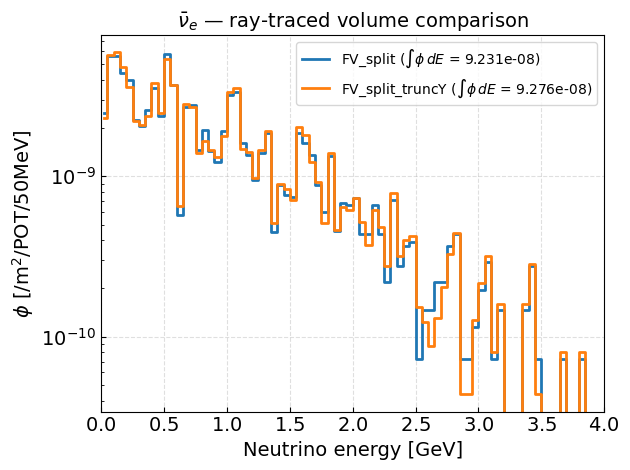

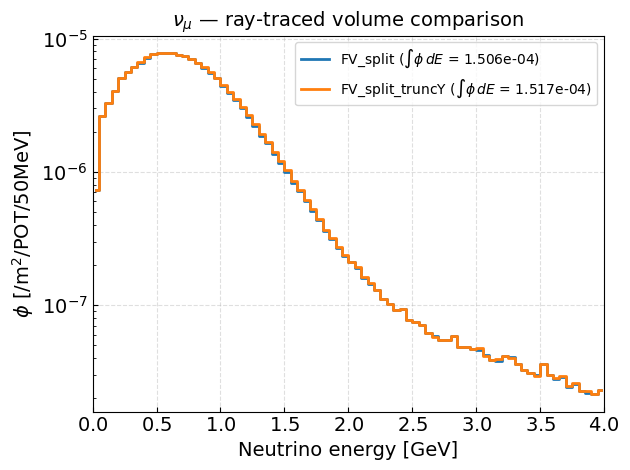

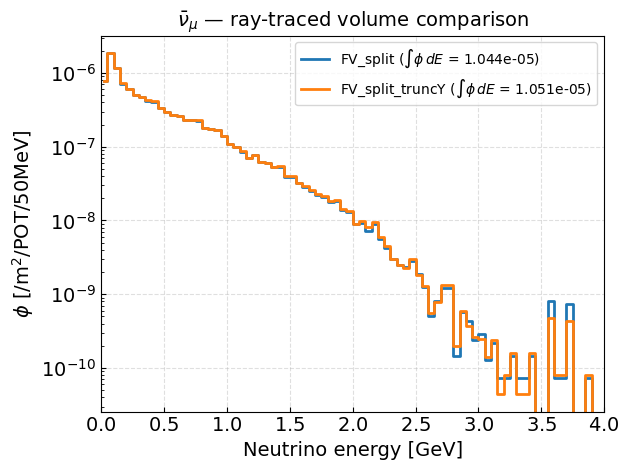

In [10]:
for flav in FLAVORS:
    fig, ax = plt.subplots()
    for vol_name in VOLUMES:
        spec = spectra[vol_name][flav]
        integ = float(np.sum(spec))
        ax.step(
            BIN_CENTERS,
            spec,
            where="mid",
            label=rf"{vol_name} ($\int\phi\,dE$ = {integ:.3e})",
        )
    ax.set_xlim(0, E_MAX_GEV)
    ax.set_xlabel("Neutrino energy [GeV]")
    ax.set_ylabel(r"$\phi$ [/m$^2$/POT/50MeV]")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=10)
    ax.set_title(f"{FLAVOR_LATEX[flav]} — ray-traced volume comparison")
    plt.tight_layout()
    plt.show()


## Path-length distribution per volume

Diagnostic: distribution of per-ray path length $L_i$ in the two volumes (only rays with
$L>0$). Rays in the BNB beam are highly forward-peaked so most $L$ values cluster near the
$z$-extent of the volume divided by $\cos\theta\sim 1$.


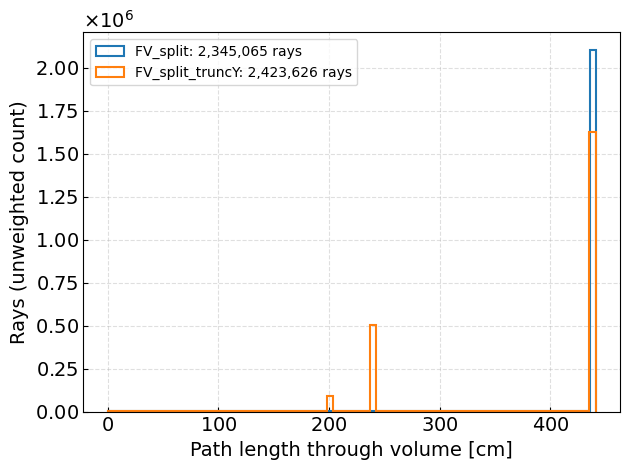

In [11]:
fig, ax = plt.subplots()
for vol_name, L in path_lengths.items():
    Lpos = L[L > 0]
    ax.hist(Lpos, bins=80, histtype="step", linewidth=1.5, label=f"{vol_name}: {len(Lpos):,} rays")
ax.set_xlabel("Path length through volume [cm]")
ax.set_ylabel("Rays (unweighted count)")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


## Cross-check vs plane-scan volume average

Re-implement the `gsimple.ipynb` plane-scan estimator over the AV footprint $|x|,|y|<200$
and average over $z$ slabs spanning the full $z$ range of `FV_split` ($10<z<450$). This is
the same window-area-normalized estimator used in `gsimple.ipynb`, but with $z$ slabs that
cover the requested FV $z$ range, so the two answers should agree at the few-percent
level (differences come from the rectangular AV vs. split-FV $x/y$ acceptance, finite $z$
sampling, and the cathode cut $|x|>10$ cm that the plane-scan does not impose).


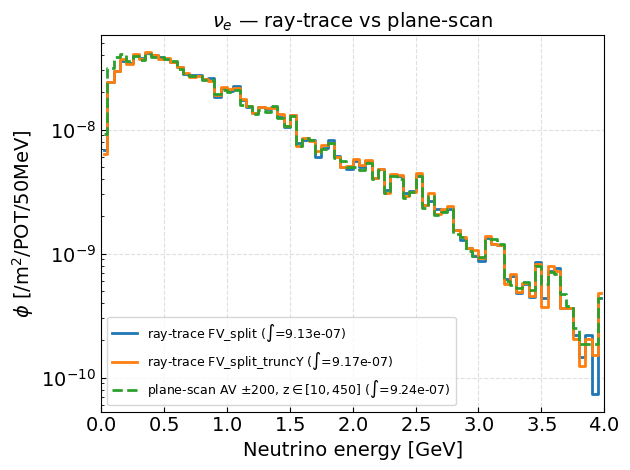

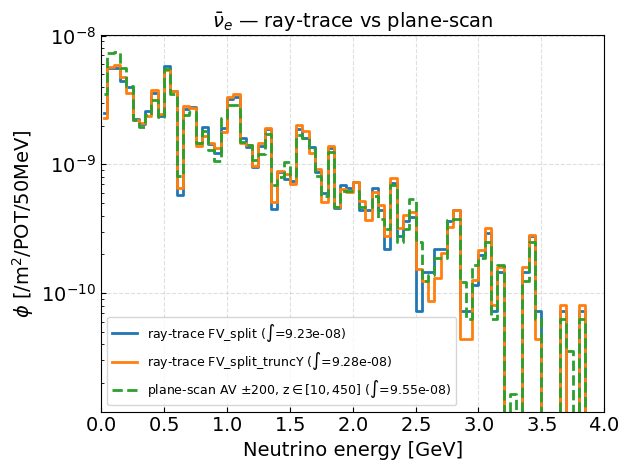

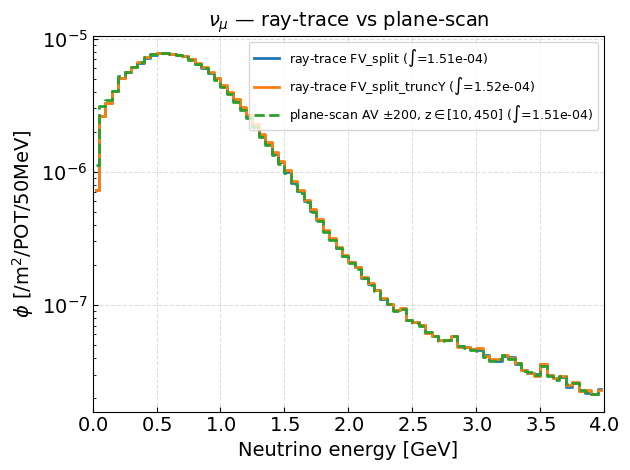

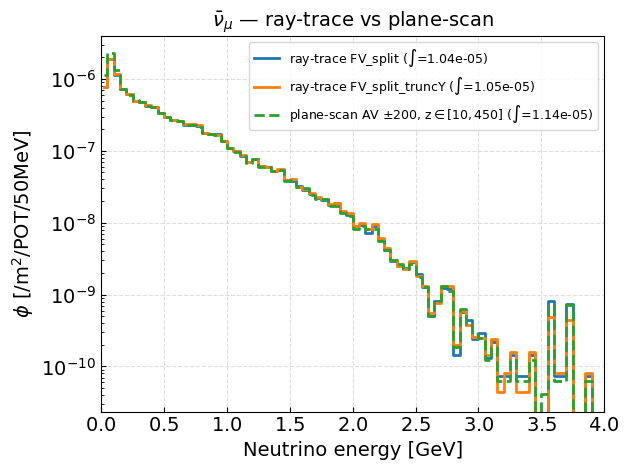

In [12]:
def _project_to_z(data, z_target_cm):
    slope_x = data["px"] / data["pz"]
    slope_y = data["py"] / data["pz"]
    dz_ = z_target_cm - data["vtxz"]
    return data["vtxx"] + slope_x * dz_, data["vtxy"] + slope_y * dz_


def _plane_spectrum(data, flavor, z_cm, x_range, y_range):
    x_cm, y_cm = _project_to_z(data, z_cm)
    pdg = PDG_BY_FLAVOR[flavor]
    m = (
        (data["pdg"] == pdg)
        & (x_cm >= x_range[0]) & (x_cm < x_range[1])
        & (y_cm >= y_range[0]) & (y_cm < y_range[1])
    )
    area_m2 = (x_range[1] - x_range[0]) * 1e-2 * (y_range[1] - y_range[0]) * 1e-2
    h, _ = np.histogram(data["E"][m], bins=E_BINS, weights=data["wgt"][m])
    return h / (area_m2 * TOTAL_POT)


Z_SCAN = np.linspace(10.0, 450.0, 23)  # ~20 cm step over the FV z range
AV_X = (-200.0, 200.0)
AV_Y = (-200.0, 200.0)

plane_volume_spec = {}
for flav in FLAVORS:
    stack = np.stack([_plane_spectrum(data, flav, z, AV_X, AV_Y) for z in Z_SCAN], axis=0)
    plane_volume_spec[flav] = stack.mean(axis=0)

for flav in FLAVORS:
    fig, ax = plt.subplots()
    ax.step(
        BIN_CENTERS, spectra["FV_split"][flav],
        where="mid",
        label=rf"ray-trace FV_split ($\int$={np.sum(spectra['FV_split'][flav]):.2e})",
    )
    ax.step(
        BIN_CENTERS, spectra["FV_split_truncY"][flav],
        where="mid",
        label=rf"ray-trace FV_split_truncY ($\int$={np.sum(spectra['FV_split_truncY'][flav]):.2e})",
    )
    ax.step(
        BIN_CENTERS, plane_volume_spec[flav],
        where="mid", linestyle="--",
        label=rf"plane-scan AV $\pm200$, z$\in[10,450]$ ($\int$={np.sum(plane_volume_spec[flav]):.2e})",
    )
    ax.set_xlim(0, E_MAX_GEV)
    ax.set_xlabel("Neutrino energy [GeV]")
    ax.set_ylabel(r"$\phi$ [/m$^2$/POT/50MeV]")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=9)
    ax.set_title(f"{FLAVOR_LATEX[flav]} — ray-trace vs plane-scan")
    plt.tight_layout()
    plt.show()


## Reload flux from `gsimple_raytrace_batch.py` outputs

If you ran [`gsimple_raytrace_batch.py`](gsimple_raytrace_batch.py), the run directory contains
`raytrace_flux_histograms.npz`, `raytrace_flux_histograms_meta.json`, `processed_files.txt`,
and `skipped_files.json`.

Arrays: **`flux_density_wvf`** has shape `(n_volume, n_flavor, n_energy)` in
$\mathrm{m}^{-2}\,\mathrm{POT}^{-1}$ per 50 MeV bin; **`hist_weighted_wvf`** holds raw
$\sum w_i L_i$ [cm] per bin before dividing by $(V\,\mathrm{POT})$.


In [6]:
from pathlib import Path
import json

BATCH_FLUX_DIR = Path("/exp/sbnd/data/users/munjung/flux/SBND_gsimple_raytrace")
BATCH_NPZ = BATCH_FLUX_DIR / "raytrace_flux_histograms.npz"
BATCH_META = BATCH_FLUX_DIR / "raytrace_flux_histograms_meta.json"

if not BATCH_NPZ.is_file():
    raise FileNotFoundError(
        f"Missing {BATCH_NPZ!s}. Run gsimple_raytrace_batch.py with --out-dir / --save-npz, "
        "or point BATCH_FLUX_DIR to that directory."
    )

batch = np.load(BATCH_NPZ, allow_pickle=True)
phi_wvf = batch["flux_density_wvf"]
nr_wvf = batch["n_rays_wvf"]
vol_keys = list(batch["volume_keys"])
vol_cm3 = batch["volume_cm3"]
BIN_BATCH = batch["BIN_CENTERS"]
total_pot_batch = float(batch["total_pot"])

if BATCH_META.is_file():
    with open(BATCH_META, encoding="utf-8") as f:
        batch_meta = json.load(f)
    print("Batch meta:", json.dumps(
        {k: batch_meta[k] for k in ("n_files_ok", "n_skipped", "n_files_attempted", "batch_size") if k in batch_meta},
        indent=2,
    ))
print("total_pot (batch)", total_pot_batch)
print("phi_wvf shape", phi_wvf.shape, "| volumes:", vol_keys)


Batch meta: {
  "n_files_ok": 5000,
  "n_skipped": 0,
  "n_files_attempted": 5000,
  "batch_size": 500
}
total_pot (batch) 50000164197.1396
phi_wvf shape (2, 4, 200) | volumes: ['FV_split', 'FV_split_truncY']


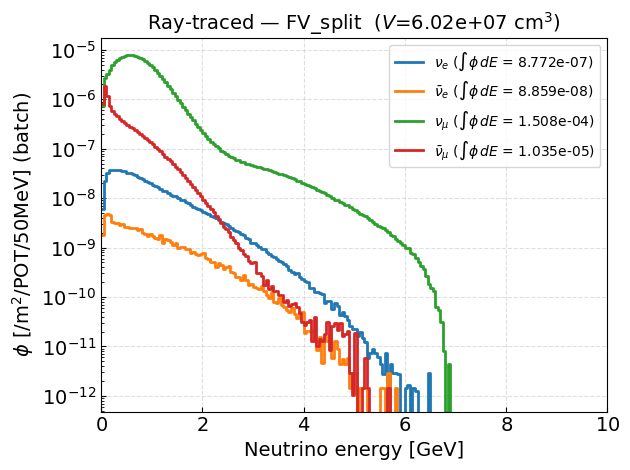

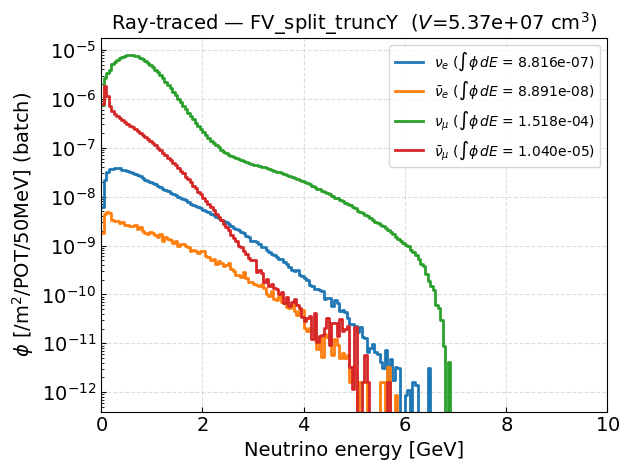

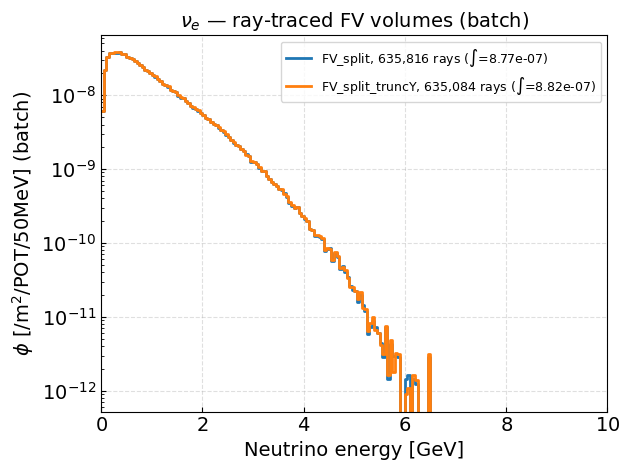

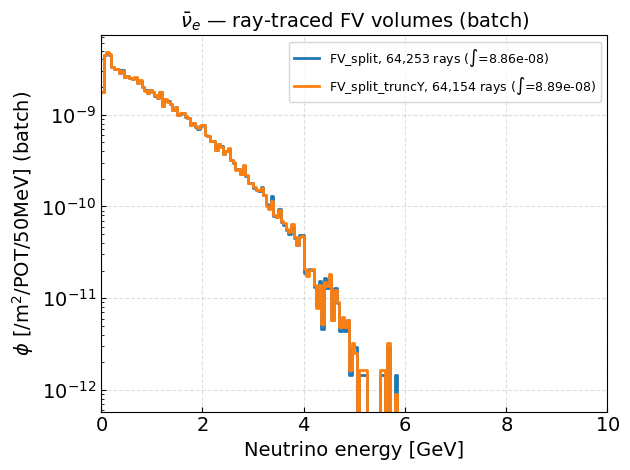

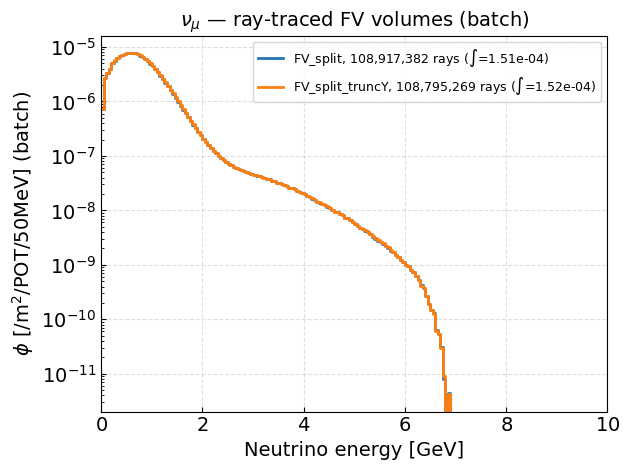

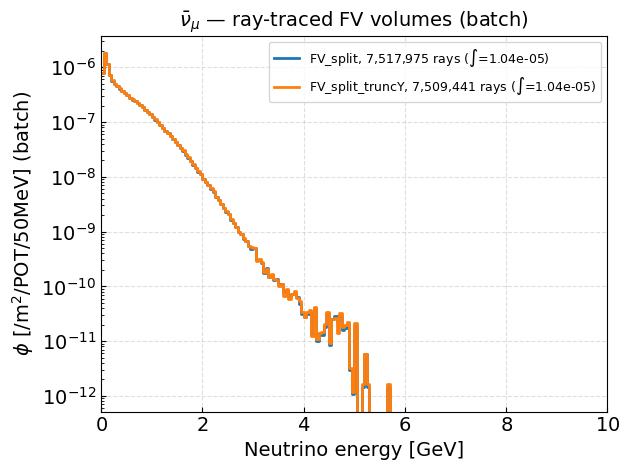

In [7]:
for iv, vname in enumerate(vol_keys):
    fig, ax = plt.subplots()
    for iflav, flav in enumerate(FLAVORS):
        spec = phi_wvf[iv, iflav, :]
        integ = float(np.sum(spec))
        ax.step(
            BIN_BATCH, spec, where="mid",
            label=rf"{FLAVOR_LATEX[flav]} ($\int\phi\,dE$ = {integ:.3e})",
        )
    ax.set_xlim(0, E_MAX_GEV)
    ax.set_xlabel("Neutrino energy [GeV]")
    ax.set_ylabel(r"$\phi$ [/m$^2$/POT/50MeV] (batch)")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=10)
    ax.set_title(f"Ray-traced — {vname}  ($V$={float(vol_cm3[iv]):.3g} cm$^3$)")
    plt.tight_layout()
    plt.show()

for iflav, flav in enumerate(FLAVORS):
    fig, ax = plt.subplots()
    for iv, vname in enumerate(vol_keys):
        spec = phi_wvf[iv, iflav, :]
        n_rays = int(nr_wvf[iv, iflav])
        integ = float(np.sum(spec))
        ax.step(
            BIN_BATCH, spec, where="mid",
            label=rf"{vname}, {n_rays:,} rays ($\int$={integ:.2e})",
        )
    ax.set_xlim(0, E_MAX_GEV)
    ax.set_xlabel("Neutrino energy [GeV]")
    ax.set_ylabel(r"$\phi$ [/m$^2$/POT/50MeV] (batch)")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=9)
    ax.set_title(f"{FLAVOR_LATEX[flav]} — ray-traced FV volumes (batch)")
    plt.tight_layout()
    plt.show()


In [8]:
# Save FV_split_truncY flux in Gen1FV_flux.root format:
# TH1D per flavor named flux_sbnd_{numu,nue,anumu,anue}, 200 bins 0--10 GeV (50 MeV),
# units [/m^2/10^6 POT] per bin (same as sbnd_original_flux.root / flux_closure).
from pathlib import Path

FLUX_ROOT_OUT = Path(
    "/exp/sbnd/data/users/munjung/xsec/flux_closure/FV_split_truncY_raytrace_flux.root"
)
FLUX_ROOT_EDGES = np.linspace(0.0, 10.0, 201)
POT_SCALE = 1.0e6

FLUX_HIST_NAME = {
    "nue": "flux_sbnd_nue",
    "nuebar": "flux_sbnd_anue",
    "numu": "flux_sbnd_numu",
    "numubar": "flux_sbnd_anumu",
}


def _fv_split_truncy_spectra():
    if "spectra" in globals() and "FV_split_truncY" in spectra:
        return spectra["FV_split_truncY"]
    if "phi_wvf" in globals() and "vol_keys" in globals():
        iv = list(vol_keys).index("FV_split_truncY")
        return {flav: phi_wvf[iv, FLAVORS.index(flav), :] for flav in FLAVORS}
    raise RuntimeError(
        "Run the ray-trace spectra cells above, or reload batch outputs containing FV_split_truncY."
    )


def _to_root_flux_values(spec):
    n_low = len(E_BINS) - 1
    spec = np.asarray(spec, dtype=np.float64)
    if spec.shape[0] != n_low:
        raise ValueError(f"expected {n_low} bins (0--{E_MAX_GEV} GeV), got {spec.shape[0]}")
    out = np.zeros(len(FLUX_ROOT_EDGES) - 1, dtype=np.float32)
    out[:n_low] = spec * POT_SCALE
    return out


trunc_specs = _fv_split_truncy_spectra()
FLUX_ROOT_OUT.parent.mkdir(parents=True, exist_ok=True)

with uproot.recreate(str(FLUX_ROOT_OUT)) as fout:
    for flav in FLAVORS:
        vals = _to_root_flux_values(trunc_specs[flav])
        fout[FLUX_HIST_NAME[flav]] = (vals, FLUX_ROOT_EDGES)

print(f"Wrote {FLUX_ROOT_OUT}")
for flav in FLAVORS:
    vals = _to_root_flux_values(trunc_specs[flav])
    print(f"  {FLUX_HIST_NAME[flav]:20s}  sum={vals.sum():.4f}  (/m^2/10^6 POT)")

Wrote /exp/sbnd/data/users/munjung/xsec/flux_closure/FV_split_truncY_raytrace_flux.root
  flux_sbnd_nue         sum=0.8816  (/m^2/10^6 POT)
  flux_sbnd_anue        sum=0.0889  (/m^2/10^6 POT)
  flux_sbnd_numu        sum=151.8012  (/m^2/10^6 POT)
  flux_sbnd_anumu       sum=10.3989  (/m^2/10^6 POT)


## Compare `FV_split_truncY` ray-trace flux vs `Gen1FV_flux.root`

Both files use TH1D histograms `flux_sbnd_*` with 200 bins from 0–10 GeV (50 MeV) in units of `/m²/10⁶ POT` per bin. `Gen1FV_flux.root` currently contains only `flux_sbnd_numu`.

Gen1FV keys: ['flux_sbnd_numu']
truncY keys: ['flux_sbnd_nue', 'flux_sbnd_anue', 'flux_sbnd_numu', 'flux_sbnd_anumu']

$\nu_\mu$ (flux_sbnd_numu)
  integral Gen1FV:     155.27552  (/m^2/10^6 POT)
  integral truncY:     151.80116
  integral ratio:      0.9776
  max |diff|/bin:      5.024e-01


/tmp/ipykernel_2565190/559868513.py:63: RuntimeWarning: invalid value encountered in divide
  rel_diff = np.where(v_ref > 0, (v_new - v_ref) / v_ref, np.nan)
/tmp/ipykernel_2565190/559868513.py:85: RuntimeWarning: invalid value encountered in divide
  ax1.step(c_ref, v_new / v_ref, where="mid", color="C2", lw=1.2)


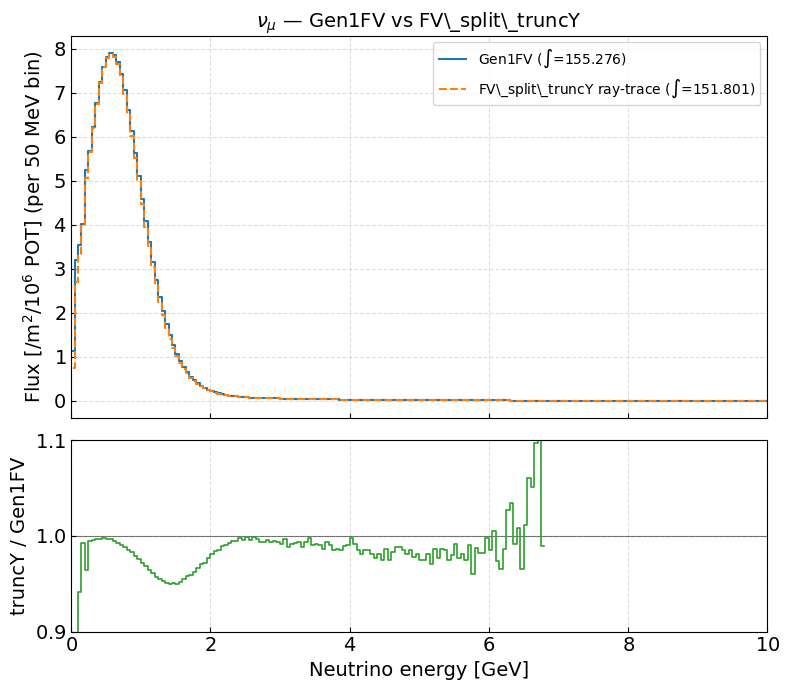

In [ ]:
GEN1FV_FLUX_ROOT = Path(
    "/exp/sbnd/data/users/munjung/xsec/flux_closure/Gen1FV_flux.root"
)

FLUX_ROOT_OUT = Path(
    # "/exp/sbnd/data/users/munjung/xsec/flux_closure/FV_split_truncY_raytrace_flux.root"
    "/exp/sbnd/data/users/munjung/flux/SBND_gsimple_raytrace/Gen1.root"
)
TRUNCY_FLUX_ROOT = FLUX_ROOT_OUT

FLUX_ROOT_EDGES = np.linspace(0.0, 10.0, 201)
POT_SCALE = 1.0e6

FLUX_HIST_NAME = {
    "nue": "flux_sbnd_nue",
    "nuebar": "flux_sbnd_anue",
    "numu": "flux_sbnd_numu",
    "numubar": "flux_sbnd_anumu",
}

if not GEN1FV_FLUX_ROOT.is_file():
    raise FileNotFoundError(GEN1FV_FLUX_ROOT)
if not TRUNCY_FLUX_ROOT.is_file():
    raise FileNotFoundError(
        f"{TRUNCY_FLUX_ROOT!s} — run the save cell above first."
    )

f_gen1 = uproot.open(GEN1FV_FLUX_ROOT)
f_trunc = uproot.open(TRUNCY_FLUX_ROOT)
print("Gen1FV keys:", [k.split(";")[0] for k in f_gen1.keys()])
print("truncY keys:", [k.split(";")[0] for k in f_trunc.keys()])


def _hist_keys(f):
    return {k.split(";")[0] for k in f.keys()}


def _load_flux_hist(f, hist_name):
    if hist_name not in _hist_keys(f):
        raise KeyError(f"{hist_name!r} not in file; keys = {sorted(_hist_keys(f))}")
    vals, edges = f[hist_name].to_numpy()
    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, edges, np.asarray(vals, dtype=np.float64)


# Gen1FV only has numu; compare that flavor plus any shared names.
compare_flavors = [flav for flav in FLAVORS if FLUX_HIST_NAME[flav] in _hist_keys(f_gen1)]
if not compare_flavors:
    compare_flavors = ["numu"]

for flav in compare_flavors:
    hname = FLUX_HIST_NAME[flav]
    c_ref, e_ref, v_ref = _load_flux_hist(f_gen1, hname)
    c_new, e_new, v_new = _load_flux_hist(f_trunc, hname)

    if not np.allclose(e_ref, e_new):
        raise ValueError(f"{hname}: bin edges differ between files")

    int_ref = float(v_ref.sum())
    int_new = float(v_new.sum())
    ratio = int_new / int_ref if int_ref else np.nan
    max_abs_diff = float(np.max(np.abs(v_new - v_ref)))
    rel_diff = np.where(v_ref > 0, (v_new - v_ref) / v_ref, np.nan)

    print(f"\n{FLAVOR_LATEX[flav]} ({hname})")
    print(f"  integral Gen1FV:     {int_ref:.5f}  (/m^2/10^6 POT)")
    print(f"  integral truncY:     {int_new:.5f}")
    print(f"  integral ratio:      {ratio:.4f}")
    print(f"  max |diff|/bin:      {max_abs_diff:.3e}")

    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

    ax0.step(c_ref, v_ref, where="mid", color="C0", lw=1.5,
             label=rf"Gen1FV ($\int$={int_ref:.3f})")
    ax0.step(c_new, v_new, where="mid", color="C1", lw=1.5, ls="--",
             label=rf"FV\_split\_truncY ray-trace ($\int$={int_new:.3f})")
    ax0.set_xlim(0, E_MAX_GEV)
    # ax0.set_yscale("log")
    ax0.set_ylabel(r"Flux [/m$^2$/10$^6$ POT] (per 50 MeV bin)")
    ax0.grid(True, alpha=0.4)
    ax0.legend(fontsize=10)
    ax0.set_title(rf"{FLAVOR_LATEX[flav]} — Gen1FV vs FV\_split\_truncY")

    ax1.axhline(1.0, color="k", lw=0.8, alpha=0.5)
    ax1.step(c_ref, v_new / v_ref, where="mid", color="C2", lw=1.2)
    ax1.set_xlabel("Neutrino energy [GeV]")
    ax1.set_ylabel("truncY / Gen1FV")
    ax1.set_xlim(0, 0.5)
    ax1.set_ylim(0.9, 1.1)
    ax1.grid(True, alpha=0.4)
    finite = rel_diff[np.isfinite(rel_diff)]
    # if finite.size:
    #     ax1.set_ylim(max(0.5, np.percentile(finite, 2)), min(2.0, np.percentile(finite, 98)))

    plt.tight_layout()
    plt.show()

In [13]:
c_new, e_new, v_new 

(array([0.025, 0.075, 0.125, 0.175, 0.225, 0.275, 0.325, 0.375, 0.425,
        0.475, 0.525, 0.575, 0.625, 0.675, 0.725, 0.775, 0.825, 0.875,
        0.925, 0.975, 1.025, 1.075, 1.125, 1.175, 1.225, 1.275, 1.325,
        1.375, 1.425, 1.475, 1.525, 1.575, 1.625, 1.675, 1.725, 1.775,
        1.825, 1.875, 1.925, 1.975, 2.025, 2.075, 2.125, 2.175, 2.225,
        2.275, 2.325, 2.375, 2.425, 2.475, 2.525, 2.575, 2.625, 2.675,
        2.725, 2.775, 2.825, 2.875, 2.925, 2.975, 3.025, 3.075, 3.125,
        3.175, 3.225, 3.275, 3.325, 3.375, 3.425, 3.475, 3.525, 3.575,
        3.625, 3.675, 3.725, 3.775, 3.825, 3.875, 3.925, 3.975, 4.025,
        4.075, 4.125, 4.175, 4.225, 4.275, 4.325, 4.375, 4.425, 4.475,
        4.525, 4.575, 4.625, 4.675, 4.725, 4.775, 4.825, 4.875, 4.925,
        4.975, 5.025, 5.075, 5.125, 5.175, 5.225, 5.275, 5.325, 5.375,
        5.425, 5.475, 5.525, 5.575, 5.625, 5.675, 5.725, 5.775, 5.825,
        5.875, 5.925, 5.975, 6.025, 6.075, 6.125, 6.175, 6.225, 6.275,
      